# Hospital Readmission Risk Predictor — Notebook 3: Baseline Models

**Prepared for:** Hospital Administration & Care Management Stakeholders  
**Prepared by:** Angeline Setiawan | **Team:** Epsilon  
**Project:** Hospital Readmission Risk Predictor — A Phased MLOps Project

## Purpose

This notebook fits and evaluates the first baseline classification model for predicting **30-day hospital readmission**. It continues directly from the Phase 2 Pre-Processing & Feature Engineering notebook.

The primary analysis dataset is the **patient-level snapshot** created in Phase 2: one row per patient, using the first eligible encounter after excluding encounters ending in in-hospital death. Phase 2 produced a time-aware 75/25 train/test split with no patient overlap. No imputation, scaling, or one-hot encoding was performed in Phase 2; those transformations are learned from the training data in this notebook.

The main baseline is **regularized logistic regression**, chosen because it is interpretable, computationally practical, and provides a strong reference point for a binary clinical-risk classification problem. Because the positive class is relatively uncommon, **PR-AUC is the primary evaluation metric**, with ROC-AUC, recall, precision, and F1 reported as secondary metrics.


## 1. Imports and Reproducibility

The preprocessing steps are placed inside a scikit-learn `Pipeline` so that imputation, scaling, and one-hot encoding are fit **only on the training data within each cross-validation fold**. This prevents preprocessing leakage.


In [1]:
# ----------------------------------------------------------------------
# 1.1 Imports
# ----------------------------------------------------------------------
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SPLITS = 5

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

print("Imports loaded.")


Imports loaded.


## 2. File Paths and Load the Phase 2 Split

Phase 2 saved the primary modeling files as:

- `data/processed/train.csv`
- `data/processed/test.csv`

If your notebook is stored in the project's `notebooks/` folder, the paths below should work without modification.


In [2]:
# ----------------------------------------------------------------------
# 2.1 Locate the processed Phase 2 datasets
# ----------------------------------------------------------------------
NOTEBOOK_DIR = os.getcwd()

# Expected when running from the repository's notebooks/ directory.
CANDIDATE_TRAIN_PATHS = [
    "../data/processed/train.csv",
    "data/processed/train.csv",
]
CANDIDATE_TEST_PATHS = [
    "../data/processed/test.csv",
    "data/processed/test.csv",
]

def first_existing(paths):
    for path in paths:
        if os.path.exists(path):
            return path
    return None

TRAIN_PATH = first_existing(CANDIDATE_TRAIN_PATHS)
TEST_PATH = first_existing(CANDIDATE_TEST_PATHS)

if TRAIN_PATH is None or TEST_PATH is None:
    raise FileNotFoundError(
        "Could not find train.csv/test.csv. Expected them in "
        "../data/processed/ or data/processed/. "
        "Update TRAIN_PATH and TEST_PATH if your repository layout differs."
    )

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print(f"Training data: {train_df.shape[0]:,} rows x {train_df.shape[1]:,} columns")
print(f"Testing data:  {test_df.shape[0]:,} rows x {test_df.shape[1]:,} columns")
print(f"Training file: {TRAIN_PATH}")
print(f"Testing file:  {TEST_PATH}")


Training data: 52,829 rows x 58 columns
Testing data:  17,610 rows x 58 columns
Training file: ../data/processed/train.csv
Testing file:  ../data/processed/test.csv


In [3]:
# ----------------------------------------------------------------------
# 2.2 Basic inventory
# ----------------------------------------------------------------------
TARGET = "readmitted_30d"

if TARGET not in train_df.columns or TARGET not in test_df.columns:
    raise KeyError(
        f"Expected target '{TARGET}' was not found in both datasets. "
        f"Training columns include: {list(train_df.columns)}"
    )

print("Target distribution — training:")
print(train_df[TARGET].value_counts(dropna=False).sort_index())
print("\nTarget distribution — testing:")
print(test_df[TARGET].value_counts(dropna=False).sort_index())

print("\nPositive-class rates:")
print(f"Train: {train_df[TARGET].mean():.2%}")
print(f"Test:  {test_df[TARGET].mean():.2%}")

print("\nFirst five rows:")
display(train_df.head())


Target distribution — training:
readmitted_30d
0    47734
1     5095
Name: count, dtype: int64

Target distribution — testing:
readmitted_30d
0    16409
1     1201
Name: count, dtype: int64

Positive-class rates:
Train: 9.64%
Test:  6.82%

First five rows:


,patient_nbr,encounter_id,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,admission_type_id_label,discharge_disposition_id_label,admission_source_id_label,readmitted_30d,max_glu_serum_tested,A1Cresult_tested,diag_1_group,diag_2_group,diag_3_group,encounter_order
0,48330783,12522,Caucasian,Female,[80-90),2,1,4,13,Missing,...,Urgent,Discharged to home,Transfer from a hospital,0,Not Tested,Not Tested,Circulatory,Circulatory,Other,0
1,63555939,15738,Caucasian,Female,[90-100),3,3,4,12,Missing,...,Elective,Discharged/transferred to SNF,Transfer from a hospital,0,Not Tested,Not Tested,Circulatory,Neoplasms,Respiratory,1
2,42519267,16680,Caucasian,Male,[40-50),1,1,7,1,Missing,...,Emergency,Discharged to home,Emergency Room,0,Not Tested,Not Tested,Neoplasms,Neoplasms,Diabetes,2
3,89869032,28236,AfricanAmerican,Female,[40-50),1,1,7,9,Missing,...,Emergency,Discharged to home,Emergency Room,0,Not Tested,Not Tested,Diabetes,Circulatory,Injury,3
4,82637451,35754,Caucasian,Male,[50-60),2,1,2,3,Missing,...,Urgent,Discharged to home,Clinic Referral,0,Not Tested,Not Tested,Circulatory,Circulatory,Diabetes,4


## 3. Define the Modeling Features

The Phase 2 design intentionally removed the original three-class `readmitted` source field after creating `readmitted_30d`, which prevents direct target leakage.

Identifiers and ordering variables are also excluded from the predictor matrix. In particular, `patient_nbr`, `encounter_id`, and `encounter_order` are identifiers/ordering aids rather than clinical predictors.

The raw ICD-9 diagnosis-code columns are excluded because Phase 2 created grouped diagnosis features (`diag_1_group`, `diag_2_group`, `diag_3_group`) specifically to reduce high cardinality and avoid an impractical one-hot representation.

The discharge disposition fields are excluded from the primary baseline because the intended use is a risk score generated around admission/early care rather than a prediction that uses information only known after discharge planning.


In [4]:
# ----------------------------------------------------------------------
# 3.1 Define exclusions and predictors
# ----------------------------------------------------------------------
ID_AND_ORDER_COLUMNS = [
    "patient_nbr",
    "encounter_id",
    "encounter_order",
]

RAW_TARGET_COLUMNS = [
    "readmitted",
]

RAW_HIGH_CARDINALITY_DIAGNOSIS_COLUMNS = [
    "diag_1",
    "diag_2",
    "diag_3",
]

# These variables describe discharge disposition and are not available
# at the intended admission-time prediction point.
DISCHARGE_COLUMNS = [
    "discharge_disposition_id",
    "discharge_disposition_id_label",
]

EXCLUDED_COLUMNS = (
    [c for c in ID_AND_ORDER_COLUMNS if c in train_df.columns]
    + [c for c in RAW_TARGET_COLUMNS if c in train_df.columns]
    + [c for c in RAW_HIGH_CARDINALITY_DIAGNOSIS_COLUMNS if c in train_df.columns]
    + [c for c in DISCHARGE_COLUMNS if c in train_df.columns]
    + [TARGET]
)

FEATURE_COLUMNS = [c for c in train_df.columns if c not in EXCLUDED_COLUMNS]

X_train = train_df[FEATURE_COLUMNS].copy()
X_test = test_df[FEATURE_COLUMNS].copy()
y_train = train_df[TARGET].astype(int).copy()
y_test = test_df[TARGET].astype(int).copy()

print(f"Number of modeling features before encoding: {len(FEATURE_COLUMNS)}")
print("\nExcluded columns:")
print(EXCLUDED_COLUMNS)
print("\nModeling features:")
print(FEATURE_COLUMNS)


Number of modeling features before encoding: 49

Excluded columns:
['patient_nbr', 'encounter_id', 'encounter_order', 'diag_1', 'diag_2', 'diag_3', 'discharge_disposition_id', 'discharge_disposition_id_label', 'readmitted_30d']

Modeling features:
['race', 'gender', 'age', 'admission_type_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'admission_type_id_label', 'admission_source_id

In [5]:
# ----------------------------------------------------------------------
# 3.2 Identify numeric and categorical variables
# ----------------------------------------------------------------------
NUMERIC_FEATURES = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
CATEGORICAL_FEATURES = [c for c in X_train.columns if c not in NUMERIC_FEATURES]

print(f"Numeric features: {len(NUMERIC_FEATURES)}")
print(NUMERIC_FEATURES)

print(f"\nCategorical features: {len(CATEGORICAL_FEATURES)}")
print(CATEGORICAL_FEATURES)


Numeric features: 10
['admission_type_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical features: 39
['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'admission_type_id_label', 'admission_source_id_label', 'max_glu_serum_tested', 'A1Cresult_tested', 'diag_1_group', 'diag_2_group', 'diag_3_group']


## 4. Preprocessing Pipeline

The preprocessing choices follow the Phase 2 plan:

- Numeric variables are median-imputed and standardized.
- Categorical variables are imputed to `"Missing"` and one-hot encoded.
- Unknown categories in the test set are ignored rather than causing an error.
- All learned preprocessing parameters are fit inside the modeling pipeline.

This is important because Phase 2 explicitly left imputation, scaling, and one-hot encoding for the modeling phase so that transformation parameters would be learned from training data rather than from the full dataset.


In [6]:
# ----------------------------------------------------------------------
# 4.1 Build preprocessing transformer
# ----------------------------------------------------------------------
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, NUMERIC_FEATURES),
        ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)

print("Preprocessing pipeline created.")


Preprocessing pipeline created.


# 5. Baseline Model: Logistic Regression

Logistic regression is used as the primary baseline because it gives a transparent relationship between predictors and the log-odds of 30-day readmission. It also provides a useful benchmark before moving to more flexible models during hyperparameter tuning and model evaluation.

L2 regularization is retained as a default safeguard against unstable estimates after one-hot encoding. The regularization strength is intentionally kept at the standard baseline value (`C=1.0`) rather than tuned in this notebook; tuning is reserved for the next phase.


In [7]:
# ----------------------------------------------------------------------
# 5.1 Primary baseline: regularized logistic regression
# ----------------------------------------------------------------------
baseline_logistic = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                penalty="l2",
                C=1.0,
                solver="liblinear",
                max_iter=2000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

print(baseline_logistic)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['admission_type_id',
                                                   'admission_source_id',
                                                   'time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emerg

## 6. Five-Fold Cross-Validation

Cross-validation is performed **only on the training partition**. The held-out test set is not used for model selection.

Because the outcome is imbalanced, stratification is used so that each fold retains approximately the same positive-class proportion. The final evaluation remains the time-aware Phase 2 test set, which was constructed from later patient snapshots.


In [8]:
# ----------------------------------------------------------------------
# 6.1 Stratified 5-fold CV on the training set
# ----------------------------------------------------------------------
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

SCORING = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "accuracy": "accuracy",
}

cv_results = cross_validate(
    baseline_logistic,
    X_train,
    y_train,
    cv=cv,
    scoring=SCORING,
    return_train_score=True,
    n_jobs=-1,
)

cv_summary = pd.DataFrame({
    "Metric": [
        "PR-AUC",
        "ROC-AUC",
        "Precision",
        "Recall",
        "F1",
        "Accuracy",
    ],
    "CV Mean": [
        cv_results["test_pr_auc"].mean(),
        cv_results["test_roc_auc"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_accuracy"].mean(),
    ],
    "CV SD": [
        cv_results["test_pr_auc"].std(),
        cv_results["test_roc_auc"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_accuracy"].std(),
    ],
})

cv_summary.round(4)


,Metric,CV Mean,CV SD
0,PR-AUC,0.1597,0.0038
1,ROC-AUC,0.6326,0.0022
2,Precision,0.4317,0.1004
3,Recall,0.0049,0.0022
4,F1,0.0097,0.0044
5,Accuracy,0.9034,0.0001


### Cross-validation interpretation

The cross-validation table gives an estimate of how stable the baseline is across different training/validation partitions. The mean and standard deviation should be reported together rather than relying on one fold.

The most important value for this project is **PR-AUC**, because the positive readmission class is substantially smaller than the negative class. Accuracy is retained only as a secondary descriptive metric.


In [11]:
# ----------------------------------------------------------------------
# 6.2 Check training-vs-validation performance for overfitting
# ----------------------------------------------------------------------
overfit_summary = pd.DataFrame({
    "Metric": ["PR-AUC", "ROC-AUC", "F1"],
    "Mean Training Score": [
        cv_results["train_pr_auc"].mean(),
        cv_results["train_roc_auc"].mean(),
        cv_results["train_f1"].mean(),
    ],
    "Mean Validation Score": [
        cv_results["test_pr_auc"].mean(),
        cv_results["test_roc_auc"].mean(),
        cv_results["test_f1"].mean(),
    ],
})

overfit_summary["Train - Validation"] = (
    overfit_summary["Mean Training Score"]
    - overfit_summary["Mean Validation Score"]
)

overfit_summary.round(4)


,Metric,Mean Training Score,Mean Validation Score,Train - Validation
0,PR-AUC,0.1715,0.1597,0.0119
1,ROC-AUC,0.6534,0.6326,0.0208
2,F1,0.0100,0.0097,0.0003


## 7. Fit the Baseline on the Full Training Set

After cross-validation, the baseline is fit once on all available training patients. The test set remains untouched until this point.


In [12]:
# ----------------------------------------------------------------------
# 7.1 Fit final baseline using training data only
# ----------------------------------------------------------------------
baseline_logistic.fit(X_train, y_train)

print("Baseline logistic regression fitted.")


Baseline logistic regression fitted.


## 8. Test-Set Evaluation

The following metrics are calculated once on the Phase 2 time-aware test set:

- **PR-AUC:** primary metric
- **ROC-AUC:** secondary ranking metric
- **Precision:** proportion of predicted positives that are actually positive
- **Recall:** proportion of actual readmissions detected
- **F1:** harmonic mean of precision and recall
- **Accuracy:** overall classification accuracy, interpreted cautiously because of class imbalance

The default classification threshold is 0.50. Threshold optimization is intentionally left for the model-evaluation/tuning phase.


In [13]:
# ----------------------------------------------------------------------
# 8.1 Generate predictions
# ----------------------------------------------------------------------
y_test_prob = baseline_logistic.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= 0.50).astype(int)

test_metrics = pd.DataFrame({
    "Metric": [
        "PR-AUC",
        "ROC-AUC",
        "Precision",
        "Recall",
        "F1",
        "Accuracy",
    ],
    "Test Score": [
        average_precision_score(y_test, y_test_prob),
        roc_auc_score(y_test, y_test_prob),
        precision_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0),
        accuracy_score(y_test, y_test_pred),
    ],
})

test_metrics.round(4)


,Metric,Test Score
0,PR-AUC,0.1083
1,ROC-AUC,0.6046
2,Precision,0.3000
3,Recall,0.0025
4,F1,0.0050
5,Accuracy,0.9316


In [14]:
# ----------------------------------------------------------------------
# 8.2 Classification report
# ----------------------------------------------------------------------
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Not readmitted <30d", "Readmitted <30d"],
    zero_division=0,
))

print("Confusion matrix:")
cm = confusion_matrix(y_test, y_test_pred)
display(pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"],
))


                     precision    recall  f1-score   support

Not readmitted <30d       0.93      1.00      0.96     16409
    Readmitted <30d       0.30      0.00      0.00      1201

           accuracy                           0.93     17610
          macro avg       0.62      0.50      0.48     17610
       weighted avg       0.89      0.93      0.90     17610

Confusion matrix:


,Predicted 0,Predicted 1
Actual 0,16402,7
Actual 1,1198,3


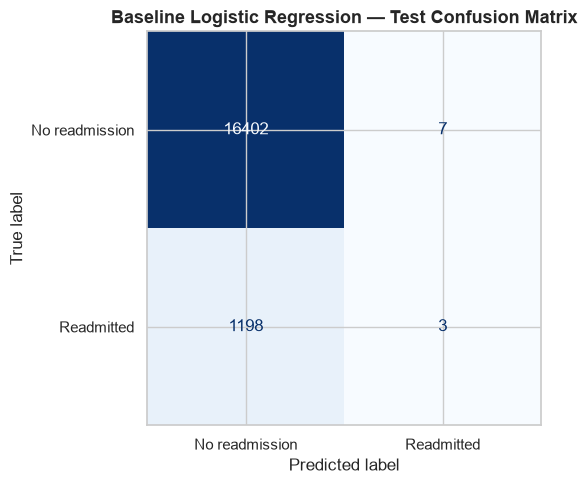

In [15]:
# ----------------------------------------------------------------------
# 8.3 Confusion matrix visualization
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No readmission", "Readmitted"]
).plot(ax=ax, values_format="d", cmap="Blues", colorbar=False)

ax.set_title("Baseline Logistic Regression — Test Confusion Matrix")
plt.tight_layout()
plt.show()


## 9. ROC and Precision-Recall Curves

The PR curve is emphasized because it shows the precision/recall trade-off for the minority positive class. A high ROC-AUC by itself can look favorable even when positive-class performance is limited under class imbalance.


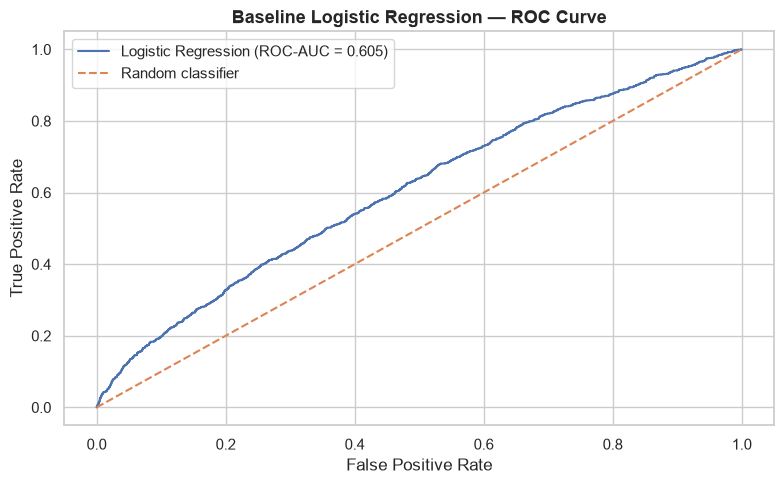

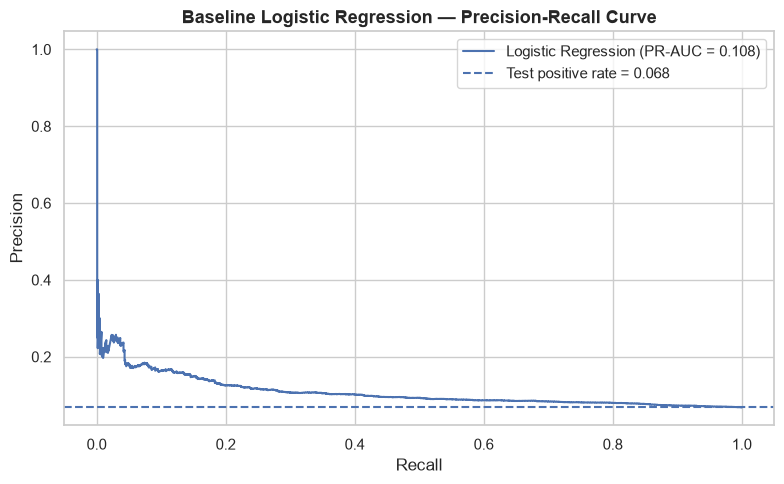

In [16]:
# ----------------------------------------------------------------------
# 9.1 ROC and PR curves
# ----------------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
precision, recall, _ = precision_recall_curve(y_test, y_test_prob)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fpr, tpr, label=f"Logistic Regression (ROC-AUC = {roc_auc_score(y_test, y_test_prob):.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
ax.set_title("Baseline Logistic Regression — ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
baseline_rate = y_test.mean()
ax.plot(
    recall,
    precision,
    label=f"Logistic Regression (PR-AUC = {average_precision_score(y_test, y_test_prob):.3f})"
)
ax.axhline(
    baseline_rate,
    linestyle="--",
    label=f"Test positive rate = {baseline_rate:.3f}"
)
ax.set_title("Baseline Logistic Regression — Precision-Recall Curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
plt.tight_layout()
plt.show()


# 10. Model Assumptions and Diagnostics

The baseline logistic regression does not require normally distributed predictors or normally distributed residuals. The relevant assumptions/conditions considered here are:

1. **Independent observations.** The primary dataset contains one row per patient, and Phase 2 verified zero patient overlap between training and testing.
2. **Linearity in the log-odds for continuous predictors.** This is assessed as a heuristic using binned relationships between each continuous predictor and the empirical log-odds of readmission.
3. **No severe multicollinearity.** Numeric-feature VIF is examined as a screening diagnostic. One-hot categorical variables are not included in the VIF calculation because dummy-variable structure can make naive VIF interpretation misleading.
4. **No obvious perfect-separation/convergence problem.** The model is regularized and convergence is checked after fitting.
5. **Calibration.** Calibration is examined as an additional risk-model diagnostic, although calibration is not the primary metric for this week's baseline report.


In [17]:
# ----------------------------------------------------------------------
# 10.1 Independence / patient-overlap check
# ----------------------------------------------------------------------
if "patient_nbr" in train_df.columns and "patient_nbr" in test_df.columns:
    patient_overlap = set(train_df["patient_nbr"]).intersection(set(test_df["patient_nbr"]))
    print(f"Patients appearing in both training and testing sets: {len(patient_overlap)}")
    assert len(patient_overlap) == 0, "Patient overlap detected."

print("Independence check: primary dataset is one row per patient and the Phase 2 split has zero patient overlap.")


Patients appearing in both training and testing sets: 0
Independence check: primary dataset is one row per patient and the Phase 2 split has zero patient overlap.


In [18]:
# ----------------------------------------------------------------------
# 10.2 Multicollinearity screening with VIF
# ----------------------------------------------------------------------
# VIF is calculated on the original numeric predictors only.
# The constant is intentionally excluded from the reported table.
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    vif_input = X_train[NUMERIC_FEATURES].copy()
    vif_input = vif_input.replace([np.inf, -np.inf], np.nan)
    vif_input = vif_input.fillna(vif_input.median(numeric_only=True))

    # Remove zero-variance numeric variables because their VIF is undefined.
    nunique = vif_input.nunique()
    vif_cols = [c for c in vif_input.columns if nunique[c] > 1]

    vif_values = []
    for i, col in enumerate(vif_cols):
        vif_values.append({
            "Feature": col,
            "VIF": variance_inflation_factor(vif_input[vif_cols].values, i)
        })

    vif_df = pd.DataFrame(vif_values).sort_values("VIF", ascending=False)
    display(vif_df.round(2))

    print("\nHeuristic: VIF values around 5+ deserve attention; values around 10+ suggest potentially severe multicollinearity.")
except ImportError:
    print("statsmodels is not installed. Run: pip install statsmodels")


,Feature,VIF
9,number_diagnoses,8.33
5,num_medications,6.97
3,num_lab_procedures,5.97
2,time_in_hospital,4.33
0,admission_type_id,2.84
1,admission_source_id,2.83
4,num_procedures,2.09
8,number_inpatient,1.14
6,number_outpatient,1.09
7,number_emergency,1.08



Heuristic: VIF values around 5+ deserve attention; values around 10+ suggest potentially severe multicollinearity.


Continuous variables evaluated: 7
['admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient']


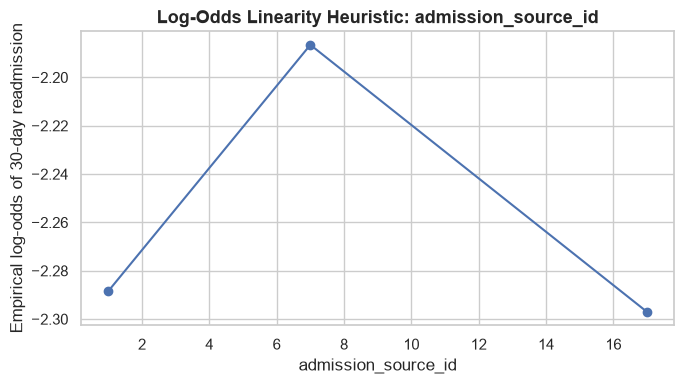

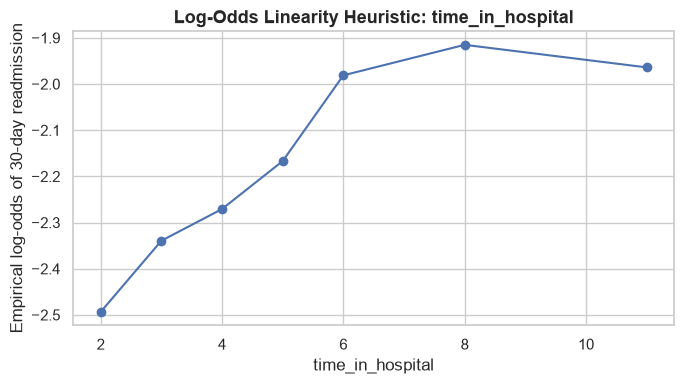

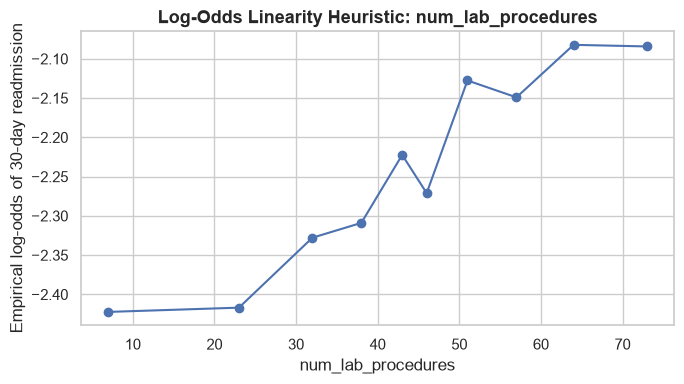

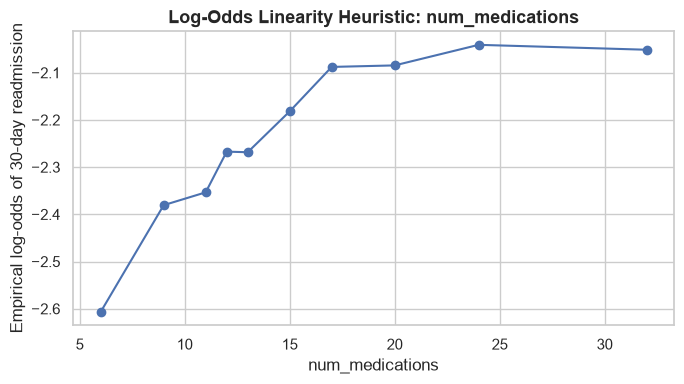

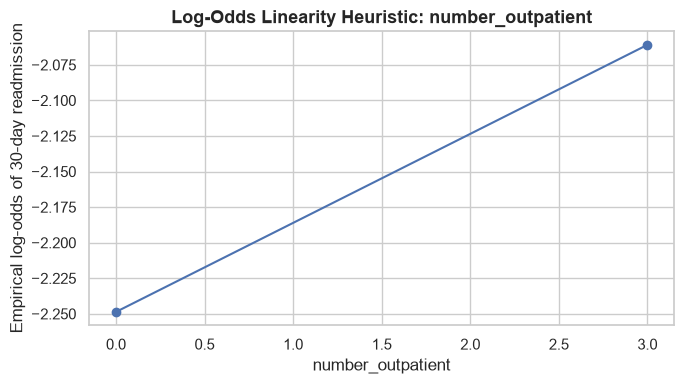

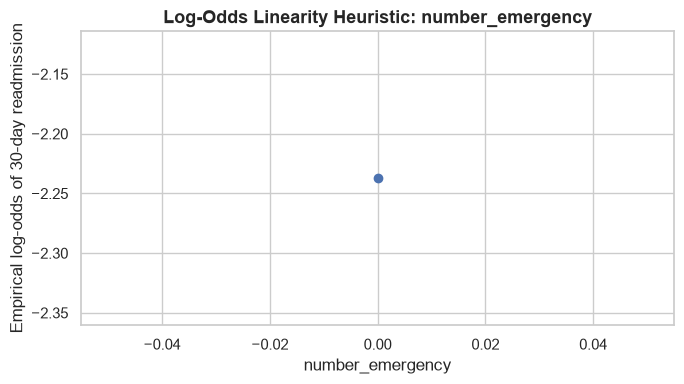

In [19]:
# ----------------------------------------------------------------------
# 10.3 Linearity-in-the-log-odds heuristic
# ----------------------------------------------------------------------
# For each continuous predictor, bin training observations into deciles
# and compare the empirical log-odds of readmission to the bin median.
# This is a diagnostic heuristic, not a formal proof of linearity.

def log_odds(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

linearity_candidates = [
    c for c in NUMERIC_FEATURES
    if X_train[c].nunique(dropna=True) >= 10
]

print(f"Continuous variables evaluated: {len(linearity_candidates)}")
print(linearity_candidates)

# Plot up to six variables to keep the notebook readable.
plot_vars = linearity_candidates[:6]

for col in plot_vars:
    temp = pd.DataFrame({
        "x": X_train[col],
        "y": y_train
    }).dropna()

    if temp["x"].nunique() < 10:
        continue

    temp["bin"] = pd.qcut(temp["x"], q=10, duplicates="drop")
    grouped = temp.groupby("bin", observed=True).agg(
        x_median=("x", "median"),
        event_rate=("y", "mean"),
        n=("y", "size")
    ).reset_index()

    grouped["log_odds"] = grouped["event_rate"].map(log_odds)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(grouped["x_median"], grouped["log_odds"], marker="o")
    ax.set_title(f"Log-Odds Linearity Heuristic: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Empirical log-odds of 30-day readmission")
    plt.tight_layout()
    plt.show()


### How to interpret the linearity plots

A roughly straight and smoothly changing relationship supports the logistic-regression linearity assumption for that predictor. Strong curvature or a clear U-shape suggests that a nonlinear transformation, splines, bins, or a more flexible model may be useful later.

These plots are **heuristics**, not definitive tests. If a variable shows obvious nonlinearity, it should be considered during next week's feature refinement/tuning rather than silently ignored.


In [20]:
# ----------------------------------------------------------------------
# 10.4 Convergence / separation check
# ----------------------------------------------------------------------
logistic_model = baseline_logistic.named_steps["model"]

print("Number of solver iterations used:", logistic_model.n_iter_)
print("Maximum iterations allowed:", logistic_model.max_iter)

if np.all(logistic_model.n_iter_ < logistic_model.max_iter):
    print("Convergence check: model converged before the maximum iteration limit.")
else:
    print("WARNING: model reached the iteration limit; investigate convergence before relying on coefficients.")


Number of solver iterations used: [14]
Maximum iterations allowed: 2000
Convergence check: model converged before the maximum iteration limit.


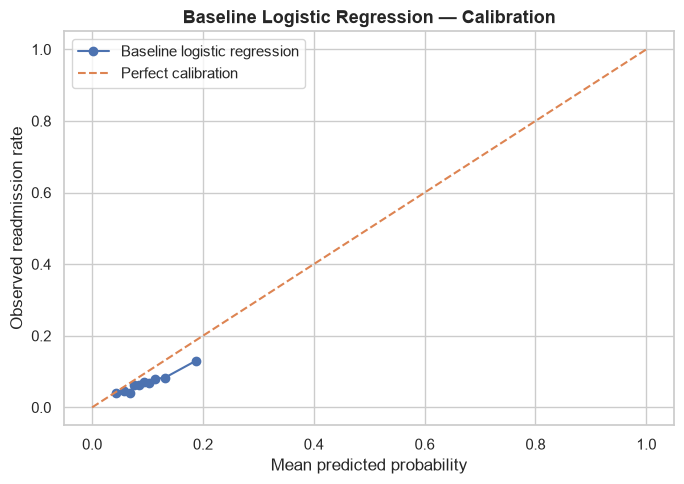

In [21]:
# ----------------------------------------------------------------------
# 10.5 Calibration curve
# ----------------------------------------------------------------------
prob_true, prob_pred = calibration_curve(
    y_test,
    y_test_prob,
    n_bins=10,
    strategy="quantile"
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(prob_pred, prob_true, marker="o", label="Baseline logistic regression")
ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
ax.set_title("Baseline Logistic Regression — Calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed readmission rate")
ax.legend()
plt.tight_layout()
plt.show()


# 11. Coefficient Interpretation

Logistic regression coefficients describe changes in the **log-odds** of 30-day readmission. For interpretability, coefficients are converted to odds ratios using `exp(coefficient)`.

Because categorical variables were one-hot encoded, each categorical coefficient is interpreted relative to the reference category selected by the encoder. Coefficients are associations within the fitted model and should not be interpreted as causal effects.


In [22]:
# ----------------------------------------------------------------------
# 11.1 Extract coefficient names and odds ratios
# ----------------------------------------------------------------------
fitted_preprocessor = baseline_logistic.named_steps["preprocessor"]
fitted_model = baseline_logistic.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()
coefficients = fitted_model.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Odds_Ratio": np.exp(coefficients),
    "Abs_Coefficient": np.abs(coefficients),
})

top_positive = coef_df.sort_values("Coefficient", ascending=False).head(15)
top_negative = coef_df.sort_values("Coefficient", ascending=True).head(15)

print("Top positive coefficients:")
display(top_positive[["Feature", "Coefficient", "Odds_Ratio"]].round(4))

print("Top negative coefficients:")
display(top_negative[["Feature", "Coefficient", "Odds_Ratio"]].round(4))


Top positive coefficients:


,Feature,Coefficient,Odds_Ratio
59,cat__medical_specialty_Hematology/Oncology,0.8189,2.2681
46,cat__medical_specialty_AllergyandImmunology,0.7427,2.1017
69,cat__medical_specialty_Oncology,0.7331,2.0815
107,cat__medical_specialty_Surgery-Plastic,0.6903,1.9943
128,cat__repaglinide_Up,0.6266,1.8713
81,cat__medical_specialty_Pediatrics-Hematology-O...,0.5678,1.7643
89,cat__medical_specialty_Psychiatry,0.5020,1.6521
163,cat__acarbose_Up,0.4573,1.5797
95,cat__medical_specialty_Radiology,0.4525,1.5723
85,cat__medical_specialty_PhysicalMedicineandReha...,0.4507,1.5695


Top negative coefficients:


,Feature,Coefficient,Odds_Ratio
80,cat__medical_specialty_Pediatrics-Endocrinology,-1.3822,0.2510
100,cat__medical_specialty_Surgery-Cardiovascular,-0.8713,0.4184
74,cat__medical_specialty_Otolaryngology,-0.7599,0.4677
57,cat__medical_specialty_Gynecology,-0.7477,0.4735
119,cat__A1Cresult_Missing,-0.7165,0.4885
132,cat__nateglinide_Up,-0.6292,0.5330
125,cat__repaglinide_Down,-0.6233,0.5362
78,cat__medical_specialty_Pediatrics-CriticalCare,-0.6123,0.5421
212,cat__A1Cresult_tested_Tested,-0.5756,0.5624
194,cat__admission_type_id_label_Trauma Center,-0.5684,0.5664


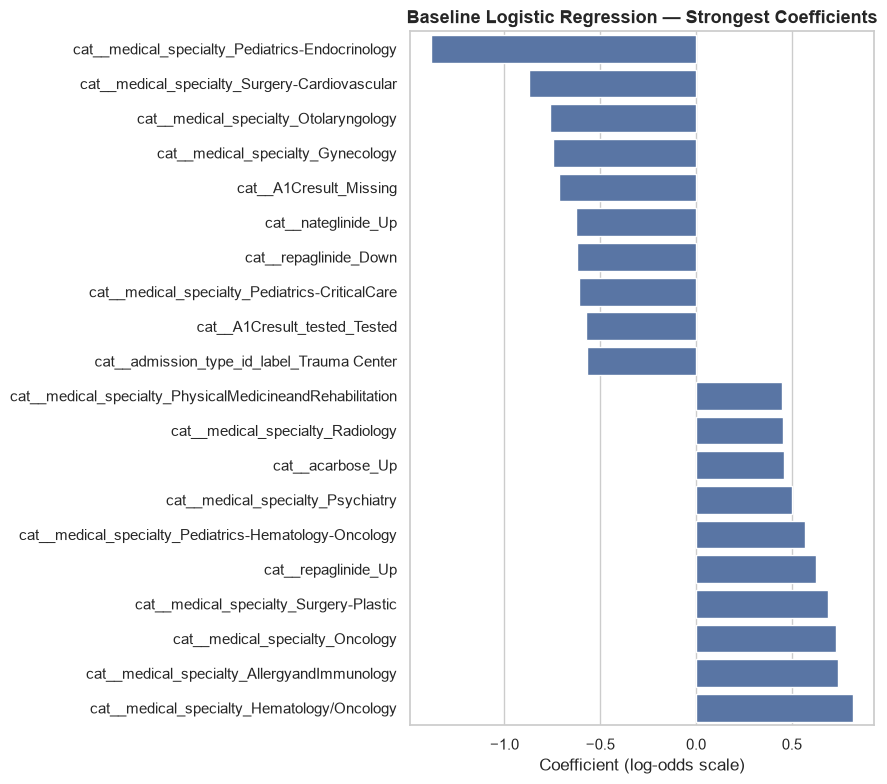

In [23]:
# ----------------------------------------------------------------------
# 11.2 Plot strongest coefficients
# ----------------------------------------------------------------------
coef_plot = pd.concat([
    coef_df.nsmallest(10, "Coefficient"),
    coef_df.nlargest(10, "Coefficient")
]).drop_duplicates("Feature").sort_values("Coefficient")

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(
    data=coef_plot,
    x="Coefficient",
    y="Feature",
    ax=ax
)
ax.set_title("Baseline Logistic Regression — Strongest Coefficients")
ax.set_xlabel("Coefficient (log-odds scale)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


# 12. Baseline Model Summary

Use the cells below to produce a compact set of numbers for the written S5 report. The values are generated directly from the fitted model rather than manually entered.


In [24]:
# ----------------------------------------------------------------------
# 12.1 Report-ready summary table
# ----------------------------------------------------------------------
report_summary = pd.DataFrame({
    "Item": [
        "Training patients",
        "Testing patients",
        "Training positive rate",
        "Testing positive rate",
        "5-fold CV PR-AUC",
        "5-fold CV ROC-AUC",
        "Test PR-AUC",
        "Test ROC-AUC",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Test Accuracy",
    ],
    "Value": [
        f"{len(train_df):,}",
        f"{len(test_df):,}",
        f"{y_train.mean():.2%}",
        f"{y_test.mean():.2%}",
        f"{cv_results['test_pr_auc'].mean():.4f}",
        f"{cv_results['test_roc_auc'].mean():.4f}",
        f"{average_precision_score(y_test, y_test_prob):.4f}",
        f"{roc_auc_score(y_test, y_test_prob):.4f}",
        f"{precision_score(y_test, y_test_pred, zero_division=0):.4f}",
        f"{recall_score(y_test, y_test_pred, zero_division=0):.4f}",
        f"{f1_score(y_test, y_test_pred, zero_division=0):.4f}",
        f"{accuracy_score(y_test, y_test_pred):.4f}",
    ]
})

display(report_summary)


,Item,Value
0,Training patients,"52,829"
1,Testing patients,"17,610"
2,Training positive rate,9.64%
3,Testing positive rate,6.82%
4,5-fold CV PR-AUC,0.1597
5,5-fold CV ROC-AUC,0.6326
6,Test PR-AUC,0.1083
7,Test ROC-AUC,0.6046
8,Test Precision,0.3000
9,Test Recall,0.0025


## Preliminary Interpretation

**Fitted model:** The baseline logistic regression provides an interpretable first estimate of the relationship between the engineered patient features and 30-day readmission risk. PR-AUC is the main performance criterion because the positive class is relatively uncommon.

**Assumptions:** The strongest structural assumption is independence of observations, which is addressed by the Phase 2 one-row-per-patient design and zero patient overlap across the time-aware split. The diagnostic plots provide a heuristic check of linearity in the log-odds for continuous predictors, while VIF screens the numeric predictors for problematic multicollinearity. The convergence check documents whether the regularized model fit successfully.

**Overfitting:** Overfitting is addressed in three ways: preprocessing is learned inside the pipeline, five-fold stratified cross-validation is performed using only the training set, and L2 regularization is used in the baseline logistic regression. The training-versus-validation table should be examined for a large performance gap. The final test set is used only after model fitting and cross-validation.

**Important:** Replace this paragraph's qualitative language with the actual numerical results generated above when preparing the final S5 report. Do not manually invent or round results that are not shown by the notebook.


# 13. Next Steps

The baseline is intended as a reference point rather than the final model. The next phase should:

1. Tune logistic-regression regularization strength (`C`) using the training data only.
2. Evaluate alternative classification models such as a tree-based ensemble.
3. Compare models using PR-AUC as the primary metric and ROC-AUC/recall as secondary metrics.
4. Investigate nonlinear relationships identified by the assumption diagnostics.
5. Evaluate whether class weighting improves clinically useful recall without producing an unacceptable precision trade-off.
6. Select a decision threshold using validation data rather than the test set.
7. Conduct a more detailed model-evaluation and error-analysis step before choosing a candidate model for deployment.


# 14. Save the Baseline Model and Results

The fitted pipeline contains both preprocessing and the logistic regression model, making it safer to reuse than saving the model and preprocessing steps separately.


In [25]:
# ----------------------------------------------------------------------
# 14.1 Save baseline model and report tables
# ----------------------------------------------------------------------
import joblib

OUTPUT_DIR_CANDIDATES = [
    "../outputs",
    "outputs",
]

OUTPUT_DIR = next(
    (p for p in OUTPUT_DIR_CANDIDATES if os.path.exists(p)),
    OUTPUT_DIR_CANDIDATES[0]
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_PATH = os.path.join(OUTPUT_DIR, "baseline_logistic_regression.joblib")
CV_RESULTS_PATH = os.path.join(OUTPUT_DIR, "baseline_cv_results.csv")
TEST_RESULTS_PATH = os.path.join(OUTPUT_DIR, "baseline_test_metrics.csv")
COEF_RESULTS_PATH = os.path.join(OUTPUT_DIR, "baseline_coefficients.csv")

joblib.dump(baseline_logistic, MODEL_PATH)
cv_summary.to_csv(CV_RESULTS_PATH, index=False)
test_metrics.to_csv(TEST_RESULTS_PATH, index=False)
coef_df.sort_values("Coefficient", ascending=False).to_csv(COEF_RESULTS_PATH, index=False)

print(f"Saved model: {MODEL_PATH}")
print(f"Saved CV results: {CV_RESULTS_PATH}")
print(f"Saved test metrics: {TEST_RESULTS_PATH}")
print(f"Saved coefficients: {COEF_RESULTS_PATH}")


Saved model: outputs\baseline_logistic_regression.joblib
Saved CV results: outputs\baseline_cv_results.csv
Saved test metrics: outputs\baseline_test_metrics.csv
Saved coefficients: outputs\baseline_coefficients.csv


# 15. Appendix — Data Dictionary / Codebook

This appendix is intentionally tied to the Phase 2 feature-engineering work. The primary dataset contains one row per patient and uses the engineered `readmitted_30d` target. The key engineered variables retained for modeling include the utilization-history fields, diagnosis-group fields, and informative missingness indicators described in the Phase 2 notebook.

## Target

| Variable | Description |
|---|---|
| `readmitted_30d` | Binary outcome: 1 if the encounter/patient snapshot corresponds to readmission within 30 days (`readmitted == "<30"`), otherwise 0. |

## Key Numeric Predictors

| Variable | Description |
|---|---|
| `time_in_hospital` | Number of days in the hospital for the encounter. |
| `num_lab_procedures` | Number of laboratory procedures during the encounter. |
| `num_procedures` | Number of procedures during the encounter. |
| `num_medications` | Number of medications during the encounter. |
| `number_outpatient` | Number of outpatient visits in the prior year. |
| `number_emergency` | Number of emergency visits in the prior year. |
| `number_inpatient` | Number of inpatient visits in the prior year. |
| `number_diagnoses` | Number of diagnoses recorded for the encounter. |

## Engineered Categorical Predictors

| Variable | Description |
|---|---|
| `race` | Patient race category, with missing values explicitly represented as `Missing`. |
| `gender` | Patient gender. |
| `age` | Age bucket. |
| `medical_specialty` | Medical specialty, with missing values represented as an explicit category. |
| `payer_code` | Payer category, with missing values represented as an explicit category. |
| `admission_type_id_label` | Human-readable admission-type category created from the Phase 2 ID mapping. |
| `admission_source_id_label` | Human-readable admission-source category created from the Phase 2 ID mapping. |
| `diag_1_group` | Grouped clinical category for the primary ICD-9 diagnosis. |
| `diag_2_group` | Grouped clinical category for the secondary ICD-9 diagnosis. |
| `diag_3_group` | Grouped clinical category for the tertiary ICD-9 diagnosis. |

## Informative Missingness Indicators

| Variable | Description |
|---|---|
| `max_glu_serum_tested` | Indicates whether maximum glucose serum testing was performed. |
| `A1Cresult_tested` | Indicates whether an A1C test was performed. |

## Modeling Exclusions

Patient identifiers, encounter identifiers/order fields, the original `readmitted` target source field, raw high-cardinality diagnosis codes, and discharge-disposition fields are excluded from the primary baseline feature matrix. The exclusion of the original `readmitted` field is a direct leakage safeguard because `readmitted_30d` was derived from it.

## Phase 2 Dataset Context

The Phase 2 notebook reported a cleaned primary patient-level dataset of **70,439 patients**, followed by a **75/25 time-aware train/test split** producing **52,829 training patients and 17,610 testing patients**. The split had **zero patient overlap**. These are the files consumed by this notebook.


# End of Notebook 3

**Primary deliverable:** fitted baseline logistic regression + cross-validation + test-set evaluation + assumption diagnostics + overfitting check.

**GitHub:** Add the URL to the team's GitHub repository in the S5 written report submission.
